# load model #

In [230]:
import torch

PATH = '../region_detection/model.pt'
model = torch.load(PATH)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Load test Image ##

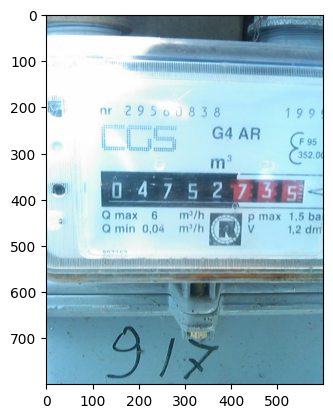

In [231]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt

path = '../data/temp_dataset/JPEGImages/02800000313175_0.jpg'
img = Image.open(path)
#data/temp_dataset/JPEGImages/02800000313255_0.jpg
plt.imshow(img)
plt.show()

## Region detection ##

In [232]:
import torchvision.transforms as T

transform = T.ToTensor()

img = transform(img)
with torch.no_grad():
    prediction = model([img])

bboxes, labels, scores = prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']
index = torch.argmax(scores).item()
bbox = bboxes[index]
x,y,w,h = bbox.detach().numpy()
x,y,w,h = int(x), int(y), int(w), int(h)
x,y,w,h

(122, 345, 519, 413)

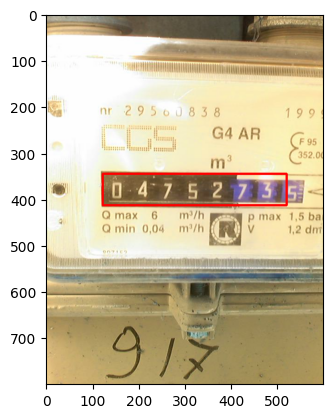

In [239]:
image = cv2.imread(path)
# for bbox in bboxes:
#     x,y,w,h = bbox.detach().numpy()
#     x,y,w,h = int(x), int(y), int(w), int(h)
cv2.rectangle(image, (x, y), (w, h), color = (255, 0, 0), thickness = 3)
plt.imshow(image)
plt.show()

## image crop ##

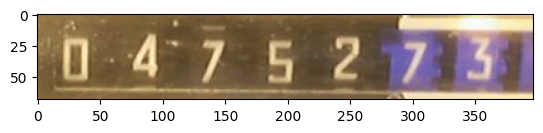

In [240]:
img = cv2.imread(path)
crop_img = img[y:h, x:w]
plt.imshow(crop_img)
plt.show()

## Recognition ##

digits read out from image:  0475273



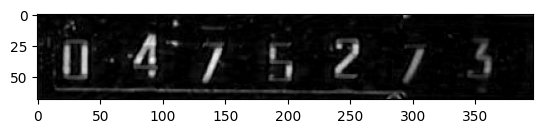

In [241]:
import pytesseract

image = crop_img
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#gray = cv2.GaussianBlur(gray, (5, 5), 0)
#gray = cv2.GaussianBlur(gray, (7, 7), 0)

# threshold the image
# ret,th1 = cv2.threshold(gray ,127,255,cv2.THRESH_BINARY_INV)
# th2 = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,2)
# th3 = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
t = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, rectKernel)
output = pytesseract.image_to_string(t, lang='eng', config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789')
print("digits read out from image: ",output)
plt.imshow(t, cmap='gray')
plt.show()